In [49]:
import rebound
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal
from scipy.integrate import quad

## Comparing Simulation With Textbook Numbers and Analytic Calculation

In [31]:
sim = rebound.Simulation()
sim.integrator = "whfast"
sim.dt = 6e-2
sim.add(m=1, hash = "Sun")
#textbook given values for 1983 where I have set inc and Omega to 0
sim.add(m=9.945786e-4,a=5.202545,e=0.0474622,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=2.85837e-4,a=9.554841,e=0.0575481,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

In [ ]:
sim.save_to_file("test.bin", interval = 100, delete_file = True)

#integrating for 10 million years
sim.integrate(1e7*2*np.pi)

In [38]:
snaps = rebound.Simulationarchive("test.bin")

e_sat = np.array([snap.particles[2].e for snap in snaps])
long_peri_sat = np.array([snap.particles[2].pomega for snap in snaps])
lambda_sat = np.array([snap.particles[2].l for snap in snaps])
lambda_J = np.array([snap.particles[1].l for snap in snaps])
time_stamp = np.array([snap.t for snap in snaps])
e_jup = np.array([snap.particles[1].e for snap in snaps])
long_peri_j = np.array([snap.particles[1].pomega for snap in snaps])

In [40]:
h = e_sat*np.sin(long_peri_sat)
k = e_sat*np.cos(long_peri_sat)
z = k + h*1j

In [47]:
fs = 1/((time_stamp[1] - time_stamp[0])/(2*np.pi))

f, pxx = signal.periodogram(z,fs=fs,window='hann',scaling='density')

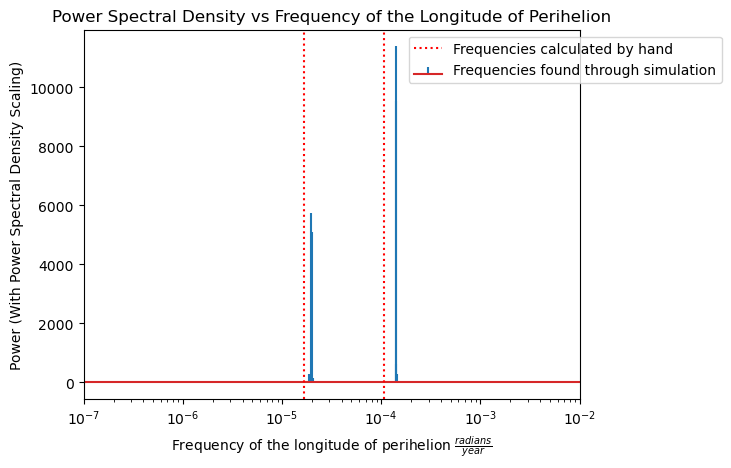

In [61]:
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.axvline(x=np.radians(9.63435e-4),c="r", ls = ':',label = 'Frequencies calculated by hand')
plt.axvline(x=np.radians(6.09908e-3),c="r", ls = ':')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency of the longitude of perihelion $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title('Power Spectral Density vs Frequency of the Longitude of Perihelion')
plt.legend(bbox_to_anchor=(1.3, 1))
plt.show()

## Comparing Simulation With Non-Textbook Numbers and Analytic Calculation

In [97]:
#defining a function to calculate g for saturn and jupiter
m_sat = 2.85837e-4
m_jup = 9.945786e-4
m_c = 1

def get_freq_of_peri(alpha,n_jup,n_sat):
    laplace_coeff_1 = np.pi**(-1)*quad(lambda x: np.cos(x)/(1-2*alpha*np.cos(x) + alpha**2)**(3/2),0,2*np.pi)[0]
    laplace_coeff_2 = np.pi**(-1)*quad(lambda x: np.cos(2*x)/(1-2*alpha*np.cos(x) + alpha**2)**(3/2),0,2*np.pi)[0]

    A_11 = n_jup*0.25*(m_sat/(m_c + m_jup))*(alpha**2)*laplace_coeff_1
    A_22 = n_sat*0.25*(m_jup/(m_c + m_sat))*alpha*laplace_coeff_1
    A_12 = -n_jup*0.25*(m_sat/(m_c + m_jup))*(alpha**2)*laplace_coeff_2
    A_21 = -n_sat*0.25*(m_jup/(m_c + m_sat))*alpha*laplace_coeff_2

    sols = np.roots([1,-(A_11 + A_22),A_11*A_22 - A_12*A_21])
    g_1 = sols[0]
    g_2 = sols[1]

    print(np.roots([1,-(A_11 + A_22),A_11*A_22 - A_12*A_21]))
    return g_1,g_2  

In [74]:
sim2 = rebound.Simulation()
sim2.integrator = "whfast"
sim2.dt = 6e-2
sim2.add(m=1, hash = "Sun")
#values not from the textbook that I made up
sim2.add(m=9.945786e-4,a=5.202545,e=0.03,inc = 0,Omega = 0,pomega=0.5*np.pi,hash="Jupiter")
#caclulated using Kepler's law with a ratio of about 3.17
sim2.add(m=2.85837e-4,a=11.219535,e=0.04,inc = 0, Omega = 0,pomega=0,hash="Saturn")

sim2.move_to_com()

alpha_2 = 5.202545/11.219535

In [106]:
g_1,g_2 = get_freq_of_peri(alpha_2, sim2.particles[1].n,sim2.particles[2].n)

[7.92888375e-06 1.64897109e-06]


In [76]:
sim2.save_to_file("test2.bin", interval = 100, delete_file = True)

#integrating for 10 million years
sim2.integrate(1e7*2*np.pi)

In [103]:
snaps2 = rebound.Simulationarchive("test2.bin")

e_sat2 = np.array([snap.particles[2].e for snap in snaps2])
time_stamp2 = np.array([snap.t for snap in snaps2])
long_peri_sat2 = np.array([snap.particles[2].pomega for snap in snaps2])
long_peri_j2 = np.array([snap.particles[1].pomega for snap in snaps2])

In [107]:
h2 = e_sat2*np.sin(long_peri_sat2)
k2 = e_sat2*np.cos(long_peri_sat2)
z2 = k2 + h2*1j

In [108]:
fs2 = 1/((time_stamp2[1] - time_stamp2[0])/(2*np.pi))

f2, pxx2 = signal.periodogram(z2,fs=fs2,window='hann',scaling='density')

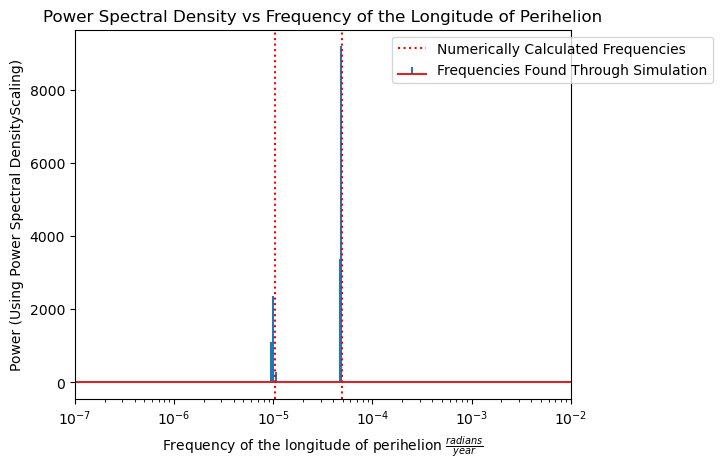

In [110]:
plt.stem(f2*2*np.pi,pxx2,markerfmt = "none",label = 'Frequencies Found Through Simulation')
plt.xscale('log')
plt.axvline(x=g_1*2*np.pi,c="r", ls = ':',label='Numerically Calculated Frequencies')
plt.axvline(x=g_2*2*np.pi,c="r", ls = ':')
plt.ylabel('Power (Using Power Spectral DensityScaling)')
plt.xlabel(r"Frequency of the longitude of perihelion $\frac{radians}{year}$")
plt.title('Power Spectral Density vs Frequency of the Longitude of Perihelion')
plt.legend(bbox_to_anchor=(1.3, 1))
plt.xlim(1e-7,1e-2)
plt.show()

## Confirming the way scipy Periodogram Works

In [71]:
#creating a sine wave with frequency of 1 radian/year
test_freq = 1
test_samples = np.linspace(0,1000,10000)
fs3 = 1/(test_samples[1] - test_samples[0])

test_z = np.exp(1j * test_freq * test_samples)

f3,pxx3 = signal.periodogram(test_z,fs=fs3,window='hann',scaling='density')

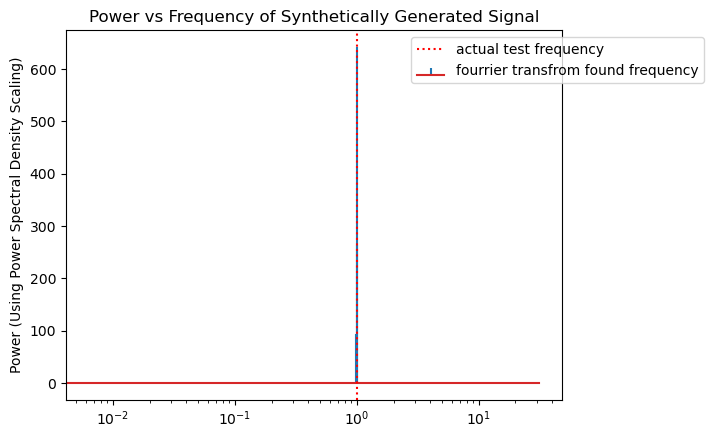

In [72]:
plt.stem(f3*2*np.pi,pxx3,markerfmt = "none",label = 'fourrier transfrom found frequency')
plt.axvline(x=1,c='r',ls=':',label = 'actual test frequency')
plt.xscale('log')
plt.legend(bbox_to_anchor=(1.3, 1))
plt.ylabel('Power (Using Power Spectral Density Scaling)')
plt.title('Power vs Frequency of Synthetically Generated Signal')
plt.show()